<a href="https://colab.research.google.com/github/lara-ms/Aula-M06/blob/main/ATV_10_Lara_Siecola.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Nome: Lara Moreira Siécola
## Matrícula: 2365

---

# Atividade 10 - Integradora

Uma equipe de engenharia está analisando o sistema de resfriamento de um reator químico acoplado a uma malha de tubulação.

O trabalho tem **duas etapas conectadas**:

1. **Etapa 1 — Sistemas Lineares:** a temperatura em regime permanente de 3 nós de junção da malha de tubulação é modelada por um sistema linear $A\cdot x = b$, resolvido pelo **Método de Gauss-Seidel**.
2. **Etapa 2 — Ajuste Não Linear:** a evolução da temperatura de um desses nós **ao longo do tempo**, durante o resfriamento transiente, segue um comportamento não linear (exponencial amortecido com componente oscilatória), ajustado pelo **Método de Gauss-Newton**.

**A conexão entre as duas etapas:** o método de Gauss-Newton, usado na Etapa 2, precisa resolver um sistema linear a cada iteração:

$$ (J^T J)\,\Delta = -J^T r $$

Nas atividades anteriores esse sistema era resolvido com `np.linalg.solve` (método direto). Nesta atividade, você vai **resolver esse sistema usando a sua própria implementação do Gauss-Seidel** (Etapa 1), integrando os dois métodos estudados.

---

## Personalização por Matrícula

**Todo o sistema linear da Etapa 1 e a estimativa inicial da Etapa 2 dependem da sua matrícula**.

Extraia três dígitos da sua matrícula da seguinte forma:

$$d_1 = matrícula \%  5 \qquad d_2 = \left\lfloor \dfrac{matrícula}{10} \right\rfloor \% 5 \qquad d_3 = \left\lfloor \dfrac{matrícula}{100} \right\rfloor \% 5$$

Esses valores serão usados para:
- Ajustar o vetor $b$ do sistema linear da Etapa 1.
- Ajustar a estimativa inicial $p_0$ do ajuste não linear da Etapa 2.

**Implemente a célula abaixo com a sua matrícula.** Todo o restante da atividade depende deste valor.

**Importante: Use/adapte as funções de atividades anteriores. Implementações diferentes serão desconsideradas.**

In [46]:
# TODO: substitua pelo valor da sua matrícula
matricula = 2365  # <-- coloque aqui sua matrícula

d1 = matricula % 5
d2 = (matricula // 10) % 5
d3 = (matricula // 100) % 5

print(f"Matrícula: {matricula}")
print(f"d1 = {d1}  |  d2 = {d2}  |  d3 = {d3}")

Matrícula: 2365
d1 = 0  |  d2 = 1  |  d3 = 3


---

# Etapa 1 — Sistema Linear e Método de Gauss-Seidel

A malha de tubulação possui 3 nós de interesse ($T_1$, $T_2$, $T_3$). O balanço térmico resultou no sistema:

$$10T_1 - T_2 + 2T_3 = 6 + d_1$$
$$-T_1 + 11T_2 - T_3 = 25 + d_2$$
$$2T_1 - T_2 + 10T_3 = -11 + d_3$$

onde $d_1$, $d_2$, $d_3$ são os valores calculados a partir da sua matrícula.

In [47]:
from IPython.display import display

# Bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

### Parte 1.1 — Montagem do Sistema Personalizado

Monte a matriz `A` e o vetor `b` usando `d1`, `d2`, `d3` calculados a partir da sua matrícula. Exiba a tabela de coeficientes.

In [48]:
# matriz A com os valores de coeficientes antes do igual
A = np.array([[10, -1, 2], [-1, 11, -1], [2, -1, 10]])

# vetor b com os valores de d's somados com coeficientes depois do igual
b = np.array([6 + d1, 25 + d2, -11 + d3])

# montando a tabela com todos os dados (pego de exercicio passado ATV_4)
tabela = pd.DataFrame(A, columns=["T1", "T2", "T3"], index=["Eq. 1", "Eq. 2", "Eq. 3"])
tabela["b"] = b
display(tabela)

,T1,T2,T3,b
Eq. 1,10,-1,2,6
Eq. 2,-1,11,-1,26
Eq. 3,2,-1,10,-8


### Parte 1.2 — Verificação da Convergência (Dominância Diagonal)

Verifique se a matriz `A` do seu sistema personalizado é estritamente diagonalmente dominante, usando a função `eh_diagonalmente_dominante`.

In [49]:
# funcao de atividades passadas ATV_4 e verificacao tbm
def eh_diagonalmente_dominante(A):
    n = A.shape[0]
    dominante = True
    for i in range(n):
        diagonal = np.abs(A[i, i])
        soma_resto = np.sum(np.abs(A[i, :])) - diagonal
        print(f"Linha {i+1}: |a_{{{i+1}{i+1}}}| = {diagonal:.2f}  |  soma dos demais = {soma_resto:.2f}  ->",
            "OK" if diagonal > soma_resto else "NÃO satisfaz")
        if diagonal <= soma_resto:
            dominante = False
    return dominante

# verificando se a matriz é diaginalmente dominante
dominante = eh_diagonalmente_dominante(A)

if dominante:
    print("\nA matriz A é estritamente diagonalmente dominante.")
else:
    print("\nA matriz A NÃO é estritamente diagonalmente dominante.")

Linha 1: |a_{11}| = 10.00  |  soma dos demais = 3.00  -> OK
Linha 2: |a_{22}| = 11.00  |  soma dos demais = 2.00  -> OK
Linha 3: |a_{33}| = 10.00  |  soma dos demais = 3.00  -> OK

A matriz A é estritamente diagonalmente dominante.


**Formulário — Critério de Dominância Diagonal**

$$|a_{ii}| > \sum_{\substack{j=1 \\ j \neq i}}^{n} |a_{ij}|$$

### Parte 1.3 — Resolução pelo Método de Gauss-Seidel

Resolva o sistema com:
- Estimativa inicial: $x^{(0)} = [0, 0, 0]$
- Tolerância: $\varepsilon = 10^{-4}$
- Número máximo de iterações: $50$

In [50]:
# funcao tbm tirada de exercicios passados ATV_4
def gauss_seidel(A, b, x0=None, tol=1e-4, max_iter=50):
    n = len(b)
    x = np.zeros(n) if x0 is None else x0.copy()
    historico = [x.copy()]

    for k in range(1, max_iter + 1):
        x_antigo = x.copy()
        for i in range(n):
            soma1 = np.dot(A[i, :i], x[:i])          # valores já atualizados (iteração atual)
            soma2 = np.dot(A[i, i+1:], x_antigo[i+1:])  # valores ainda não atualizados (iteração anterior)
            x[i] = (b[i] - soma1 - soma2) / A[i, i]

        historico.append(x.copy())
        erro = np.max(np.abs(x - x_antigo))

        if erro < tol:
            print(f"Convergiu na iteração {k} (erro = {erro:.2e})")
            break
    else:
        print(f"Número máximo de iterações ({max_iter}) atingido sem convergir para a tolerância definida.")

    return x, np.array(historico)

# usando o metodo, os parametros ja estao iguais aos da funcao so manter
x_final , iterancoes = gauss_seidel(A, b)

print("\nSolução:")
for i in range(len(x_final)):
    print(f"T{i+1}: {x_final[i]:.2f}")


Convergiu na iteração 5 (erro = 2.11e-05)

Solução:
T1: 0.99
T2: 2.38
T3: -0.76


**Formulário — Método de Gauss-Seidel**

$$x_i^{(k+1)} = \frac{1}{a_{ii}}\left(b_i - \sum_{j < i} a_{ij}\,x_j^{(k+1)} - \sum_{j > i} a_{ij}\,x_j^{(k)}\right)$$

**Critério de Parada:**

$$\max_i \left| x_i^{(k+1)} - x_i^{(k)} \right| < \varepsilon$$

### Parte 1.4 — Tabela de Iterações

Armazene os valores de $T_1$, $T_2$, $T_3$ obtidos em cada iteração em um DataFrame.

In [51]:
# Convertendo em um dataframe com as colunas temperaturas.
df_iteracoes = pd.DataFrame(iterancoes, columns=["T1", "T2", "T3"])

# Exibindo todas as iteraçoes
display(df_iteracoes)

,T1,T2,T3
0,0.000000,0.000000,0.000000
1,0.600000,2.418182,-0.678182
2,0.977455,2.390843,-0.756407
3,0.990366,2.384905,-0.759583
4,0.990407,2.384620,-0.759619
5,0.990386,2.384615,-0.759616


### Parte 1.5 — Comparação com a Solução Exata

Resolva o mesmo sistema (personalizado) com `np.linalg.solve` e compare com o resultado do Gauss-Seidel (Erro Absoluto e Erro Percentual).

In [52]:
# Uuilizando o metodo direto
x_exato = np.linalg.solve(A, b)

# Calculando do erro absoluto
erro_absoluto = np.abs(x_exato - x_final)

# Calculando erro percentual
erro_percentual = (erro_absoluto / np.abs(x_exato)) * 100

# Criando uma tabela para comparar melhr os valroes
df_comparacao = pd.DataFrame({
    "Soluçao Exata": x_exato,
    "Gauss-Seidel": x_final,
    "Erro Absoluto": erro_absoluto,
    "Erro Percentual (%)": erro_percentual
}, index=["T1", "T2", "T3"])

display(df_comparacao)

,Soluçao Exata,Gauss-Seidel,Erro Absoluto,Erro Percentual (%)
T1,0.990385,0.990386,1.299256e-06,0.000131
T2,2.384615,2.384615,2.442103e-07,0.000010
T3,-0.759615,-0.759616,2.842723e-07,0.000037


### Parte 1.6 — Gráfico de Convergência

Use `plot_convergencia` para visualizar a evolução do erro entre iterações.

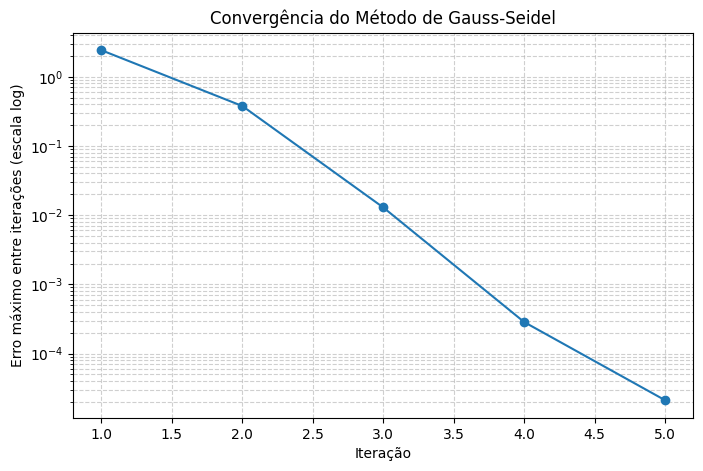

In [53]:
# funcao de exercicios passados ATV_4
def plot_convergencia(historico, titulo="Convergência do Método de Gauss-Seidel"):
    historico = np.array(historico)
    erros = np.max(np.abs(np.diff(historico, axis=0)), axis=1)
    iteracoes = np.arange(1, len(erros) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(iteracoes, erros, marker="o")
    plt.yscale("log")
    plt.xlabel("Iteração")
    plt.ylabel("Erro máximo entre iterações (escala log)")
    plt.title(titulo)
    plt.grid(True, which="both", linestyle="--", alpha=0.6)
    plt.show()

plot_convergencia(iterancoes)

---

# Etapa 2 — Ajuste Não Linear (integrando o Gauss-Seidel)

Um dos nós da malha ($T_1$) foi monitorado ao longo do tempo durante um transiente de resfriamento. O comportamento não segue um polinômio simples, exigindo um modelo não linear ("função cabeluda"):

$$T(t) = T_{amb} + A \cdot e^{-a \cdot t} + B \cdot e^{-b \cdot t} \cdot \cos(w \cdot t)$$

Os dados coletados pelo sistema SCADA estão na tabela abaixo. **Antes de usar os dados, aplique a personalização pela matrícula**: some $\left(\dfrac{d_1 - 2}{2}\right)$ a todos os valores de temperatura medidos (pequeno deslocamento vertical, específico da sua matrícula).

In [54]:
ts = np.array([0.0, 0.5, 1.0, 2.0, 3.0, 4.0, 5.0, 7.0, 9.0, 12.0])
ys_base = np.array([820.0, 695.5, 580.2, 415.0, 310.8, 240.3, 192.1, 135.4, 102.7, 75.0])

# Personalização pela matrícula: pequeno deslocamento vertical
deslocamento = (d1 - 2) / 2 # d1 = 0 --> deslocamento = -1
ys = ys_base + deslocamento

tabela_dados = pd.DataFrame({"t (min)": ts, "T medida (°C)": ys})
display(tabela_dados)

,t (min),T medida (°C)
0,0.0,819.0
1,0.5,694.5
2,1.0,579.2
3,2.0,414.0
4,3.0,309.8
5,4.0,239.3
6,5.0,191.1
7,7.0,134.4
8,9.0,101.7
9,12.0,74.0


In [55]:
# Modelo: Decaimento Exponencial Amortecido com Termo Senoidal Amortecido (fornecido)
def modelo_nao_linear(t, T_amb, A, a, B, b, w):
    return T_amb + A * np.exp(-a * t) + B * np.exp(-b * t) * np.cos(w * t)

### A integração: resolvendo o sistema normal com Gauss-Seidel

A função `ajustar_modelo` abaixo implementa o método de Gauss-Newton. A cada iteração, ela precisa resolver o sistema linear:

$$(J^T J)\,\Delta = -J^T r$$

O parâmetro `metodo_solver` controla **como** esse sistema é resolvido:
- `'direto'` → usa `np.linalg.solve` (como nas atividades anteriores).
- `'gauss_seidel'` → usa a **sua função `gauss_seidel`** implementada na Etapa 1.

Note que $(J^TJ)$ é sempre simétrica, mas **não necessariamente diagonalmente dominante** — isso é algo que você vai investigar na Parte Teórica.

In [56]:
def ajustar_modelo(t, y, params0, metodo_solver='direto', max_iter=200, tol=1e-8):
    """
    Ajusta o modelo não linear aos dados (t, y) pelo método de Gauss-Newton,
    partindo da estimativa inicial params0.

    Parâmetros:
    -----------
    t, y : array-like
        Dados medidos.
    params0 : array-like
        Estimativa inicial dos parâmetros (T_amb, A, a, B, b, w).
    metodo_solver : str
        'direto'        -> resolve (J^T J) delta = -J^T r com np.linalg.solve
        'gauss_seidel'  -> resolve (J^T J) delta = -J^T r com a função gauss_seidel (Etapa 1)
    max_iter, tol : parâmetros de parada do Gauss-Newton.

    Retorna:
    --------
    popt : array
        Parâmetros otimizados (T_amb, A, a, B, b, w).
    """
    def residuo(params):
        return modelo_nao_linear(t, *params) - y

    def jacobiano_numerico(params, eps=1e-6):
        n = len(params)
        r0 = residuo(params)
        J = np.zeros((len(t), n))
        for j in range(n):
            p_perturbado = params.copy()
            p_perturbado[j] += eps
            J[:, j] = (residuo(p_perturbado) - r0) / eps
        return J, r0

    params = np.array(params0, dtype=float)
    for _ in range(max_iter):
        J, r = jacobiano_numerico(params)
        JTJ = J.T @ J
        JTr = J.T @ r

        if metodo_solver == 'direto':
            delta = np.linalg.solve(JTJ, -JTr)
        elif metodo_solver == 'gauss_seidel':
            # TODO (Parte 2.1): chame aqui a sua função gauss_seidel da Etapa 1
            # para resolver JTJ . delta = -JTr, em vez de np.linalg.solve.
            # Dica: gauss_seidel retorna (solução, histórico) -> use apenas a solução.
            delta, _ = gauss_seidel(JTJ, -JTr, tol=1e-8, max_iter=200)
        else:
            raise ValueError("metodo_solver deve ser 'direto' ou 'gauss_seidel'")

        alpha = 1.0
        erro_atual = np.sum(r**2)
        while True:
            novo_params = params + alpha * delta
            novo_erro = np.sum(residuo(novo_params)**2)
            if novo_erro < erro_atual or alpha < 1e-8:
                break
            alpha /= 2

        params = novo_params
        if np.linalg.norm(alpha * delta) < tol:
            break

    return params  # Saídas: T_amb, A, a, B, b, w

### Parte 2.1 — Completar a Integração

Complete o trecho `TODO` da função `ajustar_modelo` acima, chamando a sua função `gauss_seidel` para resolver o sistema normal quando `metodo_solver='gauss_seidel'`.

In [57]:
# acabei mudando nela mesmo ja esta adicinado a mudanca

### Parte 2.2 — Estimativa Inicial Personalizada e Ajuste do Modelo

Use a estimativa inicial $p_0 = [25 + d_3,\ 600,\ 0.2,\ 200,\ 0.1,\ 1.5]$ e ajuste o modelo aos dados **usando `metodo_solver='gauss_seidel'`**.

Em seguida, estime a temperatura nos instantes $t = 1.5$ min, $t = 6.0$ min e $t = 10.0$ min (arredonde para duas casas decimais).

In [58]:
# estimativa inical
p0 = [25 + d3, 600, 0.2, 200, 0.1, 1.5]
# ajustando o modelo
# vai mostrar um monte de print mais é normal para a situacao nao quero ter que ajustar a matriz apenas para nao mostrar os prints
popt = ajustar_modelo(ts, ys, p0, metodo_solver='gauss_seidel')


Número máximo de iterações (200) atingido sem convergir para a tolerância definida.
Número máximo de iterações (200) atingido sem convergir para a tolerância definida.
Número máximo de iterações (200) atingido sem convergir para a tolerância definida.
Número máximo de iterações (200) atingido sem convergir para a tolerância definida.
Número máximo de iterações (200) atingido sem convergir para a tolerância definida.
Número máximo de iterações (200) atingido sem convergir para a tolerância definida.
Número máximo de iterações (200) atingido sem convergir para a tolerância definida.
Número máximo de iterações (200) atingido sem convergir para a tolerância definida.
Número máximo de iterações (200) atingido sem convergir para a tolerância definida.
Número máximo de iterações (200) atingido sem convergir para a tolerância definida.
Número máximo de iterações (200) atingido sem convergir para a tolerância definida.
Número máximo de iterações (200) atingido sem convergir para a tolerância de

In [59]:
# mostrando o resultado de forma limpa
print("Resultado obtido pelo ajuste:")
print(f"T = {popt[0]:.4f}")
print(f"A = {popt[1]:.4f}")
print(f"a = {popt[2]:.4f}")
print(f"B = {popt[3]:.4f}")
print(f"b = {popt[4]:.4f}")
print(f"w = {popt[5]:.4f}\n")

Resultado obtido pelo ajuste:
T = 55.7006
A = 613.8355
a = 0.2911
B = 150.5487
b = 0.6319
w = 0.5853



In [60]:
# tempos em instantes especificos
tempos = np.array([1.5, 6.0, 10.0])
# estimando as temps
temp_estimadas = modelo_nao_linear(tempos, *popt)

print("Temperaturas estimadas:")
for i in range(len(temp_estimadas)):
    print(f"t = {tempos[i]:.1f} min -> T = {temp_estimadas[i]:.2f} °C")

Temperaturas estimadas:
t = 1.5 min -> T = 489.61 °C
t = 6.0 min -> T = 159.55 °C
t = 10.0 min -> T = 89.34 °C


### Parte 2.3 — Comparação: Gauss-Seidel vs. Método Direto

Rode `ajustar_modelo` também com `metodo_solver='direto'` e compare os parâmetros otimizados e as estimativas de temperatura obtidas pelos dois métodos. Eles deveriam ser praticamente iguais — comente o porquê.

In [61]:
# usando agora o modo direto
popt_direto = ajustar_modelo(ts, ys, p0, metodo_solver='direto')

# comparando os parametros otimizados
df_comparacao = pd.DataFrame({
    'Parâmetro': ['T', 'A', 'a', 'B', 'b', 'w'],
    'Gauss-Seidel': popt,
    'Método Direto': popt_direto,
    'Diferença Absoluta': np.abs(popt - popt_direto)
})
display(df_comparacao)

# comparando as temperaturas estimadas
temp_estimadas_direto = modelo_nao_linear(tempos, *popt_direto)

df_comparacao_temp = pd.DataFrame({
    'Tempo ': tempos,
    'Temperatura Gauss-Seidel': temp_estimadas,
    'Temperatura Direto': temp_estimadas_direto,
    'Diferença Absoluta': np.abs(temp_estimadas - temp_estimadas_direto)
})
display(df_comparacao_temp)

,Parâmetro,Gauss-Seidel,Método Direto,Diferença Absoluta
0,T,55.700563,55.700562,7.934369e-07
1,A,613.835529,613.835523,5.651301e-06
2,a,0.291132,0.291132,3.191362e-09
3,B,150.548660,150.548666,6.620976e-06
4,b,0.631926,0.631926,1.920895e-10
5,w,0.585315,0.585315,1.341262e-08


,Tempo,Temperatura Gauss-Seidel,Temperatura Direto,Diferença Absoluta
0,1.5,489.607275,489.607275,6.523123e-09
1,6.0,159.545864,159.545864,2.861850e-08
2,10.0,89.342171,89.342171,3.898130e-08




> Os resultados obtidos são praticamente identicos pois tanto o gauss_seidel quanto o np.linalg.solve estão resolvendo a mesma equação linear. O Gauss convergiu com sucesso respeitando a tolerância exigida,sendo assim o vetor de passo calculado por ele é identico a do metodo direto levando para os mesmos resultados finais.



---

---

# Parte de Síntese — Baseada nos Seus Resultados

Esta seção final é dedicada à reflexão teórica e à interpretação crítica do trabalho realizado nas Etapas 1 e 2.

**Importante:** Não é necessário implementar nenhum código novo. Todas as respostas devem ser fundamentadas exclusivamente nas **tabelas, gráficos, verificações e valores numéricos que você obteve no seu próprio notebook** (personalizados pela sua matrícula).

---
### Pergunta 1 — Comportamento da Convergência e Taxa de Decaimento do Erro (Etapa 1)

Consulte a sua **Tabela de Iterações (Parte 1.4)** e o seu **Gráfico de Convergência (Parte 1.6)** obtidos para o seu sistema personalizado:

1. Quantas iterações o seu método de Gauss-Seidel necessitou para atingir a tolerância $\varepsilon = 10^{-4}$?
2. Mesmo que cada aluno da turma possua valores diferentes de $d_1, d_2, d_3$ (e, portanto, vetores $b$ diferentes com temperaturas finais distintas), o **número de iterações** e a **taxa de decaimento do erro** foram praticamente idênticos para todos. Explique esse fenômeno com base na teoria de convergência do Gauss-Seidel: por que a contração do vetor de erro depende exclusivamente da matriz $A$ e não do vetor de termos independentes $b$?

> 1. O método Gauss-Seidel necessitou de **5 iterações** para atingir a tolerância de $10^{-4}$.

> 2. O número de iterações e a taxa de decaimento do erro serem praticamente iguais para todos acontece porque a velocidade com que o erro encolhe a cada passo depende exclusivamente da matriz A. Já que a cada iteração o erro é multiplicado por uma matriz de iteração derivada diretamente da matriz A, e o vetor b serve apenas como ponto de chegada do sistema não afetando a taxa com que a resposta se aproxima desse ponto.

---
### Pergunta 2 — Critério de Parada por Passo Sucessivo vs. Erro Real da Solução (Etapa 1)

Na **Parte 1.5**, você comparou a solução numérica obtida pelo seu Gauss-Seidel com a solução exata fornecida por `np.linalg.solve`:

Quais foram as ordens de grandeza dos maiores **Erros Absolutos** e **Erros Percentuais** encontrados para as temperaturas $T_1, T_2, T_3$ na sua Parte 1.5?


> A ordem de grandeza do maior **Erro Absoluto** era na casa de **$10^{-6}$**.

> **Erro Percentual** maior encontrado foi **0.000131%**.

---
### Pergunta 3 — Análise Comparativa dos Solvers e Interpretação Física dos Resultados

Analise a tabela comparativa entre os métodos direto e iterativo gerada na **Parte 2.3** e a influência da sua matrícula no comportamento físico:

1. **Equivalência Numérica (Parte 2.3):** Ao comparar os 6 parâmetros otimizados ($T_{amb}, A, a, B, b, w$) e as estimativas de temperatura nos instantes $t = 1.5$, $t = 6.0$ e $t = 10.0$ min, os resultados obtidos por `np.linalg.solve` e pela sua função `gauss_seidel` foram equivalentes? Se houve alguma discrepância residual nas últimas casas decimais, a que fator numérico você a atribui?
2. **Sensibilidade Física da Personalização:** O deslocamento vertical $(d_1 - 2)/2$ nas temperaturas medidas e a alteração de $d_3$ no chute inicial provocaram alguma instabilidade na convergência do algoritmo ou o método encontrou o regime térmico de resfriamento de forma robusta?

> 1. Os resultados obtidos por ``` np.linalg.solve ``` e pela funçao ``` gauss_seidel ``` foram **equivalentes**. Eu atribuo esta discrepância residual nas ultimas casas decimais ao arredodamento que ocorre no processo.

> 2. Embora o método Gauss tenha **atingido o limite** interno de 200 iterações em alguns passos por conta das matrizes mal condicionadas, o método de Newton-Gauss **absorveu as oscilações e as ajustou**. O algoritmo mostrou **ser robusto** e conseguiu mapear de forma estável.



